In [ ]:
import os
import random
import math
from typing import Optional
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader


In [2]:
dataset = TUDataset(root='data/TUDataset', name='DD')

print(f'Dataset: {dataset.name}')
print(f'dataset size: {len(dataset)}')
print(f'Number of classes: {dataset.num_classes}')
print(f'Number of features: {dataset.num_features}')

Dataset: DD
dataset size: 1178
Number of classes: 2
Number of features: 89


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using the following device: " , device)

Using the following device:  cuda


In [4]:
torch.manual_seed(42)

dataset = dataset.shuffle()


In [5]:
labels  = dataset.y

train_val_set , test_set, _,_ = train_test_split(
    dataset,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_val_labels  = [data.y for data in train_val_set]

train_set, val_set , train_y , val_y = train_test_split(
    train_val_set,
    train_val_labels, 
    test_size=0.2,
    random_state=42,
    stratify=train_val_labels
)
print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")



Train set size: 753
Validation set size: 189
Test set size: 236


Class counts in each set:
          Set  Class  Count
0       Train      0    442
1       Train      1    311
2  Validation      0    111
3  Validation      1     78
4        Test      0    138
5        Test      1     98


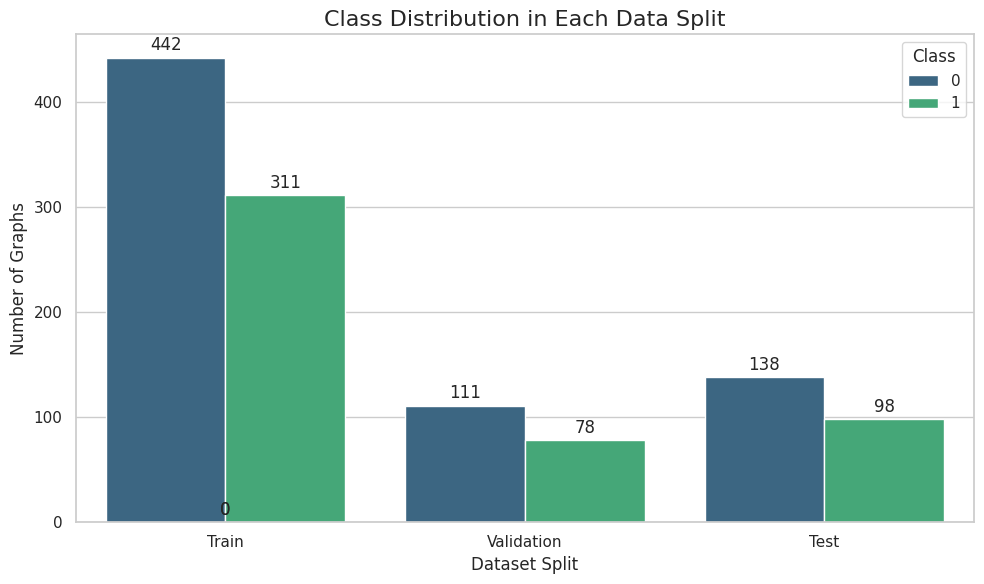

In [ ]:
import collections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


train_labels = [data.y.item() for data in train_set]
val_labels = [data.y.item() for data in val_set]
test_labels = [data.y.item() for data in test_set]

train_counts = collections.Counter(train_labels)
val_counts = collections.Counter(val_labels)
test_counts = collections.Counter(test_labels)


plot_data = []
for class_label, count in sorted(train_counts.items()):
    plot_data.append({'Set': 'Train', 'Class': class_label, 'Count': count})
for class_label, count in sorted(val_counts.items()):
    plot_data.append({'Set': 'Validation', 'Class': class_label, 'Count': count})
for class_label, count in sorted(test_counts.items()):
    plot_data.append({'Set': 'Test', 'Class': class_label, 'Count': count})

df = pd.DataFrame(plot_data)
print("Class counts in each set:")
print(df)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df, x='Set', y='Count', hue='Class', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Class Distribution in Each Data Split', fontsize=16)
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Number of Graphs', fontsize=12)
plt.legend(title='Class')
plt.tight_layout()

# Save the plot to a file and show it
plt.savefig('class_distribution.png')
plt.show()

In [74]:
class classfier(nn.Module):

    def __init__(self, hidden_channels):
        
        super(classfier, self).__init__()

        torch.manual_seed(42)

        self.conv1 = GCNConv(dataset.num_features, hidden_channels)

        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.bn2 = nn.BatchNorm1d(hidden_channels)

        #self.conv3 = GCNConv(hidden_channels, hidden_channels)

        #self.bn3 = nn.BatchNorm1d(hidden_channels)

        self.linear = nn.Linear(hidden_channels, dataset.num_classes)

    
    def forward(self, x , edge_index, batch):

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.leaky_relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.leaky_relu(x)

        #x = self.conv3(x, edge_index)

        #x = self.bn3(x)
        #x = F.relu(x)

        # Global mean pooling
        x = global_mean_pool(x, batch)

        x = F.dropout(x, training=self.training)

        x = self.linear(x)

        return x

In [79]:
batch_size = 16

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [80]:
model = classfier(hidden_channels=64)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

In [81]:
def train():

    model.train()
    
    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        out = model(data.x , data.edge_index, data.batch)

        loss = criterion(out, data.y)

        loss.backward()

        optimizer.step()

        pred = out.argmax(dim=1)

        correct = pred.eq(data.y).sum().item()

        total_loss = total_loss + loss.item()

    return total_loss / len(train_loader) , correct / len(train_loader.dataset)

def val():

    model.eval()

    total_loss = 0

    correct = 0

    with torch.no_grad():

        for data in val_loader:

            data = data.to(device)

            out = model(data.x , data.edge_index, data.batch)

            loss = criterion(out, data.y)

            total_loss = total_loss + loss.item()

            pred = out.argmax(dim=1)

            correct += pred.eq(data.y).sum().item()
    

    return total_loss / len(val_loader), correct / len(val_set)



Epoch: 001, Train Loss: 0.7189, Val Loss: 0.7129, Val Acc: 0.4074
Epoch: 002, Train Loss: 0.7158, Val Loss: 0.6891, Val Acc: 0.5026
Epoch: 003, Train Loss: 0.7005, Val Loss: 0.6779, Val Acc: 0.6455
Epoch: 004, Train Loss: 0.6919, Val Loss: 0.6693, Val Acc: 0.6349
Epoch: 005, Train Loss: 0.6715, Val Loss: 0.6643, Val Acc: 0.6296
Epoch: 006, Train Loss: 0.6777, Val Loss: 0.6598, Val Acc: 0.6296
Epoch: 007, Train Loss: 0.6594, Val Loss: 0.6573, Val Acc: 0.6296
Epoch: 008, Train Loss: 0.6591, Val Loss: 0.6527, Val Acc: 0.6455
Epoch: 009, Train Loss: 0.6675, Val Loss: 0.6509, Val Acc: 0.6508
Epoch: 010, Train Loss: 0.6545, Val Loss: 0.6486, Val Acc: 0.6561
Epoch: 011, Train Loss: 0.6696, Val Loss: 0.6454, Val Acc: 0.6667
Epoch: 012, Train Loss: 0.6523, Val Loss: 0.6437, Val Acc: 0.6667
Epoch: 013, Train Loss: 0.6411, Val Loss: 0.6419, Val Acc: 0.6720
Epoch: 014, Train Loss: 0.6615, Val Loss: 0.6393, Val Acc: 0.6667
Epoch: 015, Train Loss: 0.6426, Val Loss: 0.6372, Val Acc: 0.6614
Epoch: 016

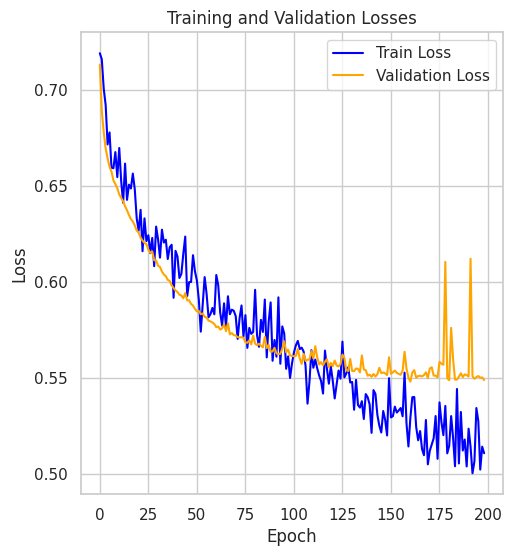

In [ ]:
train_losses = []

val_loses = []

train_accs = []

val_accs = []

for epoch in range(1, 200):

    train_loss, train_acc = train() 
    val_loss, val_acc = val()

    train_losses.append(train_loss)
    val_loses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

# Plotting the training and validation losses
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_loses, label='Validation Loss', color='orange')
plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [ ]:
def test():
    model.eval()

    total_loss = 0
    correct = 0

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y)

            total_loss += loss.item()

            pred = out.argmax(dim=1)
            correct += pred.eq(data.y).sum().item()

    return total_loss / len(test_loader), correct / len(test_set)

test_loss, test_acc = test()

print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

Test Loss: 0.5465, Test Acc: 0.7161
